# Regression: Diabetes Progression

- **Author:** Abdellah Boudlal
- **Date:** 2026-07
- **Dataset:** Scikit-Learn Diabetes dataset
- **Simple feature:** `bmi`
- **Target:** `disease_progression`

This notebook is the customized Module 4 regression project.

## Phase 4 Technical Modification

The provided example was extended by:

1. adding **MAE** to the regression evaluation;
2. adding an **actual-versus-predicted chart**;
3. saving the generated charts in `docs/images/`;
4. comparing a simple linear model with a multiple linear regression model.

## Phase 5 New Problem

The project applies regression to a different problem: predicting a quantitative measure of diabetes disease progression one year after baseline. This is an educational analysis and is not a clinical diagnosis tool.

Run all cells from top to bottom before committing and pushing the notebook.

## 1. Project Setup and Imports

The notebook uses the same regression workflow as the working example:

1. set up the environment;
2. load and prepare data;
3. split the data into training and testing sets;
4. train regression models;
5. evaluate with R-squared, MAE, RMSE, and residuals;
6. compare model complexity;
7. summarize the analyst's judgment.

In [1]:
from importlib.metadata import version
import logging
from pathlib import Path
import platform
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by looking for pyproject.toml."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return current


PROJECT_ROOT: Final[Path] = find_project_root()
IMAGES_DIR: Final[Path] = PROJECT_ROOT / "docs" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

LOG = logging.getLogger("M04_ABDELLAH")
LOG.setLevel(logging.DEBUG)
LOG.handlers.clear()

stream_handler = logging.StreamHandler()
stream_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")
)
LOG.addHandler(stream_handler)

file_handler = logging.FileHandler(PROJECT_ROOT / "project.log", encoding="utf-8")
file_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(name)s | %(message)s")
)
LOG.addHandler(file_handler)

LOG.info("=== CUSTOM REGRESSION PROJECT START ===")
LOG.info(f"project_root={PROJECT_ROOT}")
LOG.info(f"python={platform.python_version()}")
LOG.info(f"pandas={version('pandas')}")
LOG.info(f"numpy={version('numpy')}")
LOG.info(f"scikit-learn={version('scikit-learn')}")
LOG.info(f"seaborn={version('seaborn')}")
LOG.info(f"matplotlib={version('matplotlib')}")

2026-07-25 22:46:11,994 | INFO | M04_ABDELLAH | === CUSTOM REGRESSION PROJECT START ===
2026-07-25 22:46:11,996 | INFO | M04_ABDELLAH | project_root=C:\Repos\ml-04-regression
2026-07-25 22:46:11,998 | INFO | M04_ABDELLAH | python=3.14.2
2026-07-25 22:46:12,003 | INFO | M04_ABDELLAH | pandas=3.0.5
2026-07-25 22:46:12,006 | INFO | M04_ABDELLAH | numpy=2.5.1
2026-07-25 22:46:12,010 | INFO | M04_ABDELLAH | scikit-learn=1.9.0
2026-07-25 22:46:12,013 | INFO | M04_ABDELLAH | seaborn=0.13.2
2026-07-25 22:46:12,023 | INFO | M04_ABDELLAH | matplotlib=3.11.1


## 2. Load and Prepare the Data

Scikit-Learn provides this regression dataset locally, so the notebook does not need to download a file from the internet. The ten input features are standardized numeric measurements. The numeric target is a measure of disease progression one year after baseline.

For the simple regression, `bmi` is used as the single feature. Later, a multiple regression model uses all ten available features.

In [2]:
DATASET_NAME: Final[str] = "sklearn_diabetes"
SIMPLE_FEATURE: Final[str] = "bmi"
TARGET_COL: Final[str] = "disease_progression"
TARGET_LABEL: Final[str] = "Disease progression measure"

dataset = load_diabetes(as_frame=True)
df: pd.DataFrame = dataset.frame.rename(columns={"target": TARGET_COL})

FEATURE_COLS: Final[list[str]] = list(dataset.feature_names)


DATA_DIR: Final[Path] = PROJECT_ROOT / "data" / "raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DATA_PATH: Final[Path] = DATA_DIR / "diabetes_regression.csv"
df.to_csv(RAW_DATA_PATH, index=False)
LOG.info(f"Saved reproducible raw-data copy: {RAW_DATA_PATH}")

LOG.info(f"Dataset: {DATASET_NAME}")
LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
LOG.info(f"Features: {FEATURE_COLS}")
LOG.info(f"Target: {TARGET_COL}")
LOG.info(f"Missing values: {int(df.isna().sum().sum())}")
LOG.info(f"Duplicate rows: {int(df.duplicated().sum())}")

display(df.head())
display(df.describe().round(3))

2026-07-25 22:46:12,149 | INFO | M04_ABDELLAH | Saved reproducible raw-data copy: C:\Repos\ml-04-regression\data\raw\diabetes_regression.csv
2026-07-25 22:46:12,151 | INFO | M04_ABDELLAH | Dataset: sklearn_diabetes
2026-07-25 22:46:12,153 | INFO | M04_ABDELLAH | Loaded: 442 rows, 11 columns
2026-07-25 22:46:12,155 | INFO | M04_ABDELLAH | Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
2026-07-25 22:46:12,157 | INFO | M04_ABDELLAH | Target: disease_progression
2026-07-25 22:46:12,159 | INFO | M04_ABDELLAH | Missing values: 0
2026-07-25 22:46:12,169 | INFO | M04_ABDELLAH | Duplicate rows: 0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


## 3. Explore the Simple Relationship

The scatter plot shows the relationship between standardized BMI and the disease-progression target. A visible upward trend would support fitting a positive linear relationship, but the spread of points also indicates that BMI alone will not explain every outcome.

2026-07-25 22:46:12,956 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_bmi_vs_progression.png


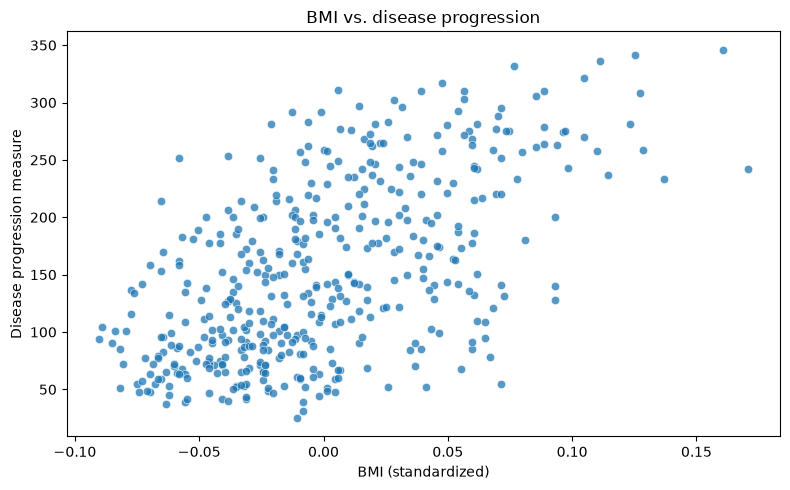

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=SIMPLE_FEATURE, y=TARGET_COL, alpha=0.75)
plt.xlabel("BMI (standardized)")
plt.ylabel(TARGET_LABEL)
plt.title("BMI vs. disease progression")
plt.tight_layout()

scatter_path = IMAGES_DIR / "phase5_bmi_vs_progression.png"
plt.savefig(scatter_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {scatter_path}")
plt.show()

## 4. Split the Data Into Training and Testing Sets

The same split is used for the simple and multiple models. The models learn only from the training data. The held-out testing data provides a more honest estimate of performance on unseen cases.

In [4]:
RANDOM_STATE: Final[int] = 42
TEST_SIZE: Final[float] = 0.20

y: np.ndarray = df[TARGET_COL].to_numpy()

X_simple: np.ndarray = df[[SIMPLE_FEATURE]].to_numpy()
X_simple_train, X_simple_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_all: np.ndarray = df[FEATURE_COLS].to_numpy()
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

LOG.info(f"Training rows: {len(y_train)}")
LOG.info(f"Testing rows: {len(y_test)}")

2026-07-25 22:46:13,201 | INFO | M04_ABDELLAH | Training rows: 353
2026-07-25 22:46:13,203 | INFO | M04_ABDELLAH | Testing rows: 89


## 5. Fit and Evaluate the Simple Linear Regression

The simple model estimates:

\[
\text{disease progression} = m(\text{BMI}) + b
\]

The Phase 4 technical modification adds **MAE** and an **actual-versus-predicted chart** to the original evaluation workflow.

In [5]:
simple_model = LinearRegression()
simple_model.fit(X_simple_train, y_train)

simple_pred: np.ndarray = simple_model.predict(X_simple_test)
simple_residuals: np.ndarray = y_test - simple_pred

simple_r2: float = float(r2_score(y_test, simple_pred))
simple_mae: float = float(mean_absolute_error(y_test, simple_pred))
simple_rmse: float = float(np.sqrt(mean_squared_error(y_test, simple_pred)))
simple_slope: float = float(simple_model.coef_[0])
simple_intercept: float = float(simple_model.intercept_)

LOG.info("SIMPLE LINEAR REGRESSION")
LOG.info(
    f"Equation: {TARGET_COL} = {simple_slope:.4f} * {SIMPLE_FEATURE} "
    f"+ {simple_intercept:.4f}"
)
LOG.info(f"R-squared: {simple_r2:.4f}")
LOG.info(f"MAE: {simple_mae:.3f}")
LOG.info(f"RMSE: {simple_rmse:.3f}")

simple_results = pd.DataFrame(
    {
        "Metric": ["R-squared", "MAE", "RMSE", "Slope", "Intercept"],
        "Value": [
            simple_r2,
            simple_mae,
            simple_rmse,
            simple_slope,
            simple_intercept,
        ],
    }
)
display(simple_results.round(4))

2026-07-25 22:46:13,234 | INFO | M04_ABDELLAH | SIMPLE LINEAR REGRESSION
2026-07-25 22:46:13,236 | INFO | M04_ABDELLAH | Equation: disease_progression = 998.5777 * bmi + 152.0034
2026-07-25 22:46:13,237 | INFO | M04_ABDELLAH | R-squared: 0.2334
2026-07-25 22:46:13,239 | INFO | M04_ABDELLAH | MAE: 52.260
2026-07-25 22:46:13,241 | INFO | M04_ABDELLAH | RMSE: 63.732


,Metric,Value
0,R-squared,0.2334
1,MAE,52.2600
2,RMSE,63.7325
3,Slope,998.5777
4,Intercept,152.0034


2026-07-25 22:46:13,949 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_simple_residuals.png


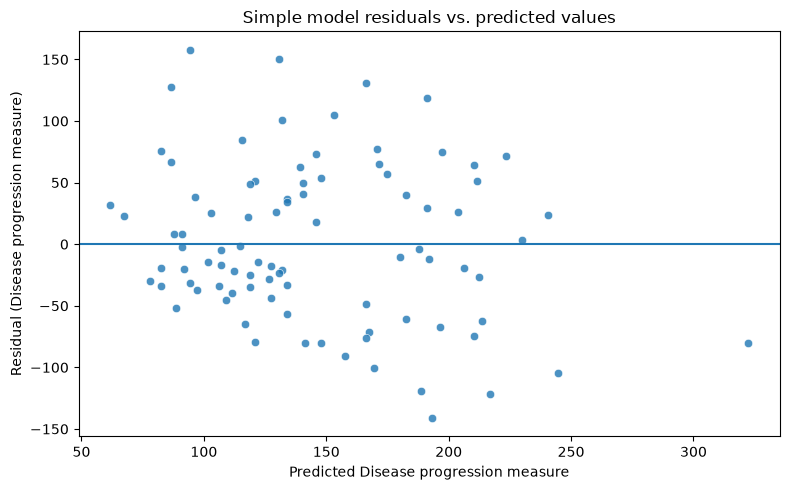

2026-07-25 22:46:14,860 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_simple_actual_vs_predicted.png


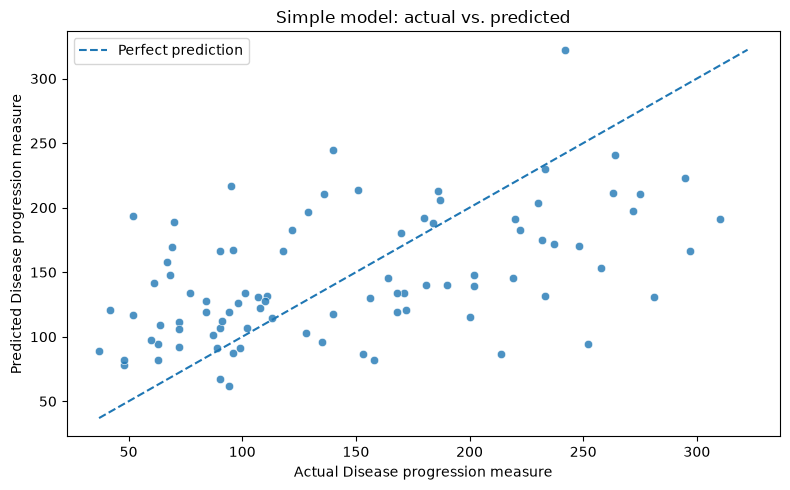

In [6]:
# Residual plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=simple_pred, y=simple_residuals, alpha=0.8)
plt.axhline(0)
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Simple model residuals vs. predicted values")
plt.tight_layout()

residual_path = IMAGES_DIR / "phase5_simple_residuals.png"
plt.savefig(residual_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {residual_path}")
plt.show()

# Phase 4 modification: actual-versus-predicted chart
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=simple_pred, alpha=0.8)
minimum = float(min(y_test.min(), simple_pred.min()))
maximum = float(max(y_test.max(), simple_pred.max()))
plt.plot(
    [minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect prediction"
)
plt.xlabel(f"Actual {TARGET_LABEL}")
plt.ylabel(f"Predicted {TARGET_LABEL}")
plt.title("Simple model: actual vs. predicted")
plt.legend()
plt.tight_layout()

actual_predicted_path = IMAGES_DIR / "phase5_simple_actual_vs_predicted.png"
plt.savefig(actual_predicted_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {actual_predicted_path}")
plt.show()

### Simple-Model Interpretation

The BMI-only model has a positive slope, so higher standardized BMI values are associated with higher predicted disease-progression values. However, BMI alone explains only part of the variation. The residuals are widely dispersed, showing that many important factors are not represented by this one-feature model.

MAE is included as the Phase 4 modification because it reports the average absolute prediction error without squaring the residuals. RMSE remains useful because it penalizes larger misses more strongly.

## 6. Examine Polynomial Complexity

Polynomial degrees 1 through 8 are compared using training and testing RMSE. A model that becomes increasingly accurate on training data while becoming worse on testing data is overfitting.

2026-07-25 22:46:15,159 | DEBUG | M04_ABDELLAH | degree= 1 train_RMSE=62.082 test_RMSE=63.732
2026-07-25 22:46:15,161 | DEBUG | M04_ABDELLAH | degree= 2 train_RMSE=62.043 test_RMSE=63.914
2026-07-25 22:46:15,164 | DEBUG | M04_ABDELLAH | degree= 3 train_RMSE=62.036 test_RMSE=63.753
2026-07-25 22:46:15,167 | DEBUG | M04_ABDELLAH | degree= 4 train_RMSE=61.896 test_RMSE=65.009
2026-07-25 22:46:15,169 | DEBUG | M04_ABDELLAH | degree= 5 train_RMSE=61.837 test_RMSE=63.921
2026-07-25 22:46:15,171 | DEBUG | M04_ABDELLAH | degree= 6 train_RMSE=61.768 test_RMSE=63.084
2026-07-25 22:46:15,173 | DEBUG | M04_ABDELLAH | degree= 7 train_RMSE=61.675 test_RMSE=64.754
2026-07-25 22:46:15,176 | DEBUG | M04_ABDELLAH | degree= 8 train_RMSE=61.116 test_RMSE=88.743


,Degree,Train RMSE,Test RMSE
0,1,62.082,63.732
1,2,62.043,63.914
2,3,62.036,63.753
3,4,61.896,65.009
4,5,61.837,63.921
5,6,61.768,63.084
6,7,61.675,64.754
7,8,61.116,88.743


2026-07-25 22:46:15,195 | INFO | M04_ABDELLAH | Lowest polynomial test RMSE: degree=6, RMSE=63.084
2026-07-25 22:46:15,688 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_polynomial_complexity.png


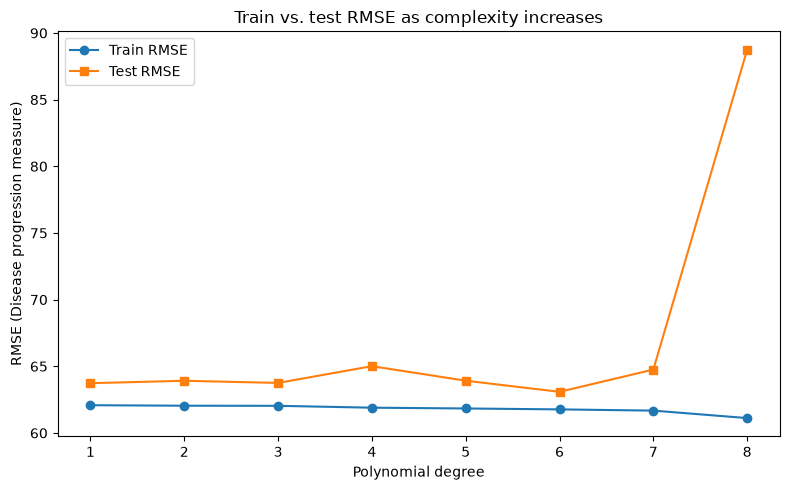

In [7]:
x_train: np.ndarray = X_simple_train.ravel()
x_test: np.ndarray = X_simple_test.ravel()

MAX_SWEEP: Final[int] = 8
degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    coeffs: np.ndarray = np.polyfit(x_train, y_train, degree)
    train_poly_pred: np.ndarray = np.polyval(coeffs, x_train)
    test_poly_pred: np.ndarray = np.polyval(coeffs, x_test)

    train_error = float(np.sqrt(np.mean((y_train - train_poly_pred) ** 2)))
    test_error = float(np.sqrt(np.mean((y_test - test_poly_pred) ** 2)))

    train_rmse.append(train_error)
    test_rmse.append(test_error)
    LOG.debug(
        f"degree={degree:2d} train_RMSE={train_error:.3f} test_RMSE={test_error:.3f}"
    )

complexity_results = pd.DataFrame(
    {
        "Degree": degrees,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
    }
)
display(complexity_results.round(3))

best_degree: int = int(
    complexity_results.loc[complexity_results["Test RMSE"].idxmin(), "Degree"]
)
best_test_rmse: float = float(complexity_results["Test RMSE"].min())
LOG.info(
    f"Lowest polynomial test RMSE: degree={best_degree}, RMSE={best_test_rmse:.3f}"
)

plt.figure(figsize=(8, 5))
plt.plot(degrees, train_rmse, marker="o", label="Train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="Test RMSE")
plt.xlabel("Polynomial degree")
plt.ylabel(f"RMSE ({TARGET_LABEL})")
plt.title("Train vs. test RMSE as complexity increases")
plt.legend()
plt.tight_layout()

complexity_path = IMAGES_DIR / "phase5_polynomial_complexity.png"
plt.savefig(complexity_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {complexity_path}")
plt.show()

### Complexity Interpretation

Degree 6 produces the lowest testing RMSE in this particular split, but its improvement over degree 1 is less than one target unit. That small improvement may not justify the much greater complexity. Degree 8 performs dramatically worse on the testing data even though its training error continues to fall, which is clear evidence of overfitting.

For communication and stability, degree 1 remains a reasonable choice for the BMI-only relationship.

## 7. Apply the Skills: Multiple Linear Regression

BMI alone cannot represent the full problem. The custom Phase 5 extension trains another linear regression model using all ten standardized features and compares it with the simple BMI-only model.

In [8]:
multiple_model = LinearRegression()
multiple_model.fit(X_all_train, y_all_train)

multiple_pred: np.ndarray = multiple_model.predict(X_all_test)
multiple_residuals: np.ndarray = y_all_test - multiple_pred

multiple_r2: float = float(r2_score(y_all_test, multiple_pred))
multiple_mae: float = float(mean_absolute_error(y_all_test, multiple_pred))
multiple_rmse: float = float(np.sqrt(mean_squared_error(y_all_test, multiple_pred)))

LOG.info("MULTIPLE LINEAR REGRESSION")
LOG.info(f"R-squared: {multiple_r2:.4f}")
LOG.info(f"MAE: {multiple_mae:.3f}")
LOG.info(f"RMSE: {multiple_rmse:.3f}")

comparison = pd.DataFrame(
    {
        "Model": ["BMI-only simple regression", "All-feature multiple regression"],
        "R-squared": [simple_r2, multiple_r2],
        "MAE": [simple_mae, multiple_mae],
        "RMSE": [simple_rmse, multiple_rmse],
    }
)
display(comparison.round(3))

2026-07-25 22:46:15,893 | INFO | M04_ABDELLAH | MULTIPLE LINEAR REGRESSION
2026-07-25 22:46:15,896 | INFO | M04_ABDELLAH | R-squared: 0.4526
2026-07-25 22:46:15,899 | INFO | M04_ABDELLAH | MAE: 42.794
2026-07-25 22:46:15,901 | INFO | M04_ABDELLAH | RMSE: 53.853


,Model,R-squared,MAE,RMSE
0,BMI-only simple regression,0.233,52.260,63.732
1,All-feature multiple regression,0.453,42.794,53.853


2026-07-25 22:46:16,384 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_multiple_actual_vs_predicted.png


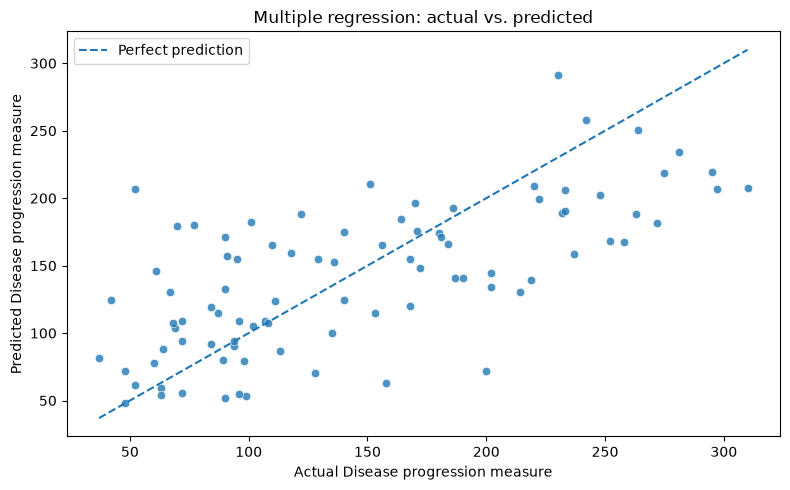

,Feature,Coefficient
4,s1,-931.489
1,sex,-241.964
0,age,37.904
9,s6,48.671
6,s3,163.420
7,s4,275.318
3,bp,347.704
5,s2,518.062
2,bmi,542.429
8,s5,736.199


2026-07-25 22:46:16,960 | INFO | M04_ABDELLAH | Saved chart: C:\Repos\ml-04-regression\docs\images\phase5_multiple_coefficients.png


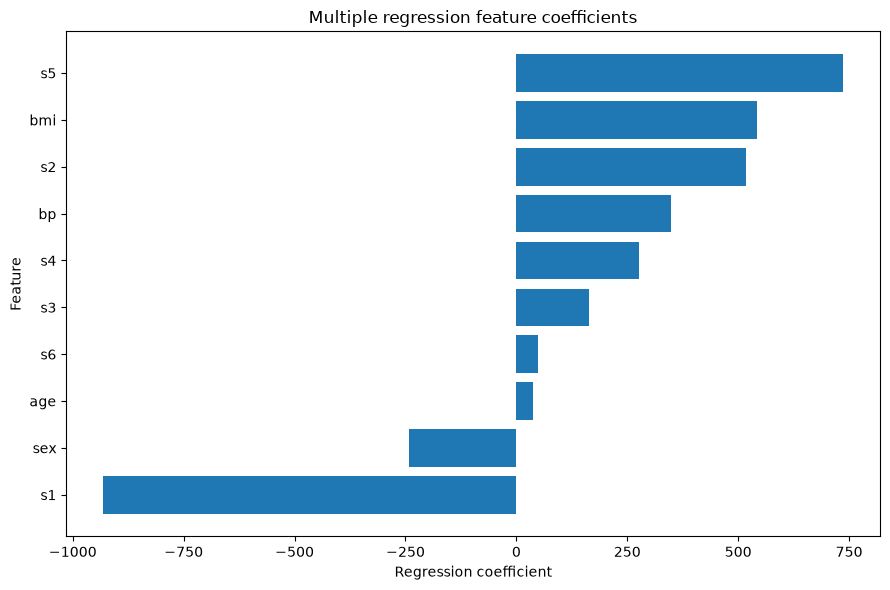

In [9]:
# Multiple-model actual-versus-predicted chart
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_all_test, y=multiple_pred, alpha=0.8)
minimum = float(min(y_all_test.min(), multiple_pred.min()))
maximum = float(max(y_all_test.max(), multiple_pred.max()))
plt.plot(
    [minimum, maximum], [minimum, maximum], linestyle="--", label="Perfect prediction"
)
plt.xlabel(f"Actual {TARGET_LABEL}")
plt.ylabel(f"Predicted {TARGET_LABEL}")
plt.title("Multiple regression: actual vs. predicted")
plt.legend()
plt.tight_layout()

multiple_actual_path = IMAGES_DIR / "phase5_multiple_actual_vs_predicted.png"
plt.savefig(multiple_actual_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {multiple_actual_path}")
plt.show()

# Coefficients are comparable because the dataset features are standardized.
coefficients = pd.DataFrame(
    {
        "Feature": FEATURE_COLS,
        "Coefficient": multiple_model.coef_,
    }
).sort_values("Coefficient")

display(coefficients.round(3))

plt.figure(figsize=(9, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Regression coefficient")
plt.ylabel("Feature")
plt.title("Multiple regression feature coefficients")
plt.tight_layout()

coefficient_path = IMAGES_DIR / "phase5_multiple_coefficients.png"
plt.savefig(coefficient_path, dpi=150, bbox_inches="tight")
LOG.info(f"Saved chart: {coefficient_path}")
plt.show()

## 8. Custom Narrative and Analyst Judgment

### Phase 4 Result

The technical modification successfully added MAE and actual-versus-predicted visualizations. These additions make the evaluation easier to interpret:

- **MAE** communicates the average absolute size of a prediction error.
- **RMSE** gives greater weight to large prediction errors.
- **Actual vs. predicted** shows how closely the predictions follow the ideal diagonal line.

### Phase 5 Result

The BMI-only model achieved approximately:

- R-squared: **0.233**
- MAE: **52.260**
- RMSE: **63.732**

The all-feature multiple regression achieved approximately:

- R-squared: **0.453**
- MAE: **42.794**
- RMSE: **53.853**

The multiple model performs better on every reported test metric. Its R-squared is higher, while its MAE and RMSE are lower. This demonstrates that BMI is informative, but it does not provide enough information by itself.

The model is useful as an educational regression baseline, but it is not accurate or complete enough for clinical decision-making. The target is influenced by multiple factors, and real medical use would require stronger validation, domain expertise, fairness checks, and appropriate governance.

### Degree Choice

Degree 6 had the lowest polynomial test RMSE for the BMI-only model, but the improvement over degree 1 was very small. Degree 8 overfit badly. Therefore, the straight-line model remains preferable when simplicity and interpretability matter.

### Next Steps

Future work could compare regularized models such as Ridge and Lasso, use cross-validation, examine coefficient stability, and evaluate whether nonlinear models improve test performance without overfitting.

In [10]:
LOG.info("========================")
LOG.info("CUSTOM PROJECT SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")
LOG.info(f"Simple model: {SIMPLE_FEATURE} -> {TARGET_COL}")
LOG.info(
    f"Simple metrics: R2={simple_r2:.4f}, MAE={simple_mae:.3f}, RMSE={simple_rmse:.3f}"
)
LOG.info(
    f"Multiple metrics: R2={multiple_r2:.4f}, MAE={multiple_mae:.3f}, "
    f"RMSE={multiple_rmse:.3f}"
)
LOG.info(f"Best polynomial test degree: {best_degree}")
LOG.info(f"Charts saved in: {IMAGES_DIR}")
LOG.info("Executed successfully!")
LOG.info("========================")

print("Executed successfully!")

2026-07-25 22:46:17,157 | INFO | M04_ABDELLAH | ========================
2026-07-25 22:46:17,159 | INFO | M04_ABDELLAH | CUSTOM PROJECT SUMMARY
2026-07-25 22:46:17,160 | INFO | M04_ABDELLAH | ========================
2026-07-25 22:46:17,161 | INFO | M04_ABDELLAH | Dataset: sklearn_diabetes
2026-07-25 22:46:17,162 | INFO | M04_ABDELLAH | Simple model: bmi -> disease_progression
2026-07-25 22:46:17,164 | INFO | M04_ABDELLAH | Simple metrics: R2=0.2334, MAE=52.260, RMSE=63.732
2026-07-25 22:46:17,166 | INFO | M04_ABDELLAH | Multiple metrics: R2=0.4526, MAE=42.794, RMSE=53.853
2026-07-25 22:46:17,167 | INFO | M04_ABDELLAH | Best polynomial test degree: 6
2026-07-25 22:46:17,168 | INFO | M04_ABDELLAH | Charts saved in: C:\Repos\ml-04-regression\docs\images
2026-07-25 22:46:17,169 | INFO | M04_ABDELLAH | Executed successfully!
2026-07-25 22:46:17,170 | INFO | M04_ABDELLAH | ========================


Executed successfully!
